# 01 - What a Hash Really Is

You use hashing thousands of times a day. Every `dict` lookup, every `set` membership test, every
`groupby`, every join, every cache: all of them are a hash table underneath, and almost all of us
treat the hash itself as the part that "makes it fast" and stop thinking there.

It is worth one notebook of thinking, because the same idea - applied slightly differently - gives
you structures that answer questions which are otherwise impossible at scale. Everything in this
project is a variation on the sentence below.

> **Hashing turns "find this thing" into "compute where it must be".**

That is the whole trick. You do not search for the key; you compute its address. And for the
computed address to be useful, the hash has to do exactly two things well:

1. **uniformity** - spread inputs evenly across the available slots, so no slot is overloaded;
2. **avalanche** - change about half the output bits when a single input bit flips, so inputs that
   look alike do not land near each other.

"Random-looking but deterministic" is the entire requirement. This notebook measures both
properties on a good hash and on a deliberately bad one, because every structure in the rest of
the project inherits its guarantees from them - and a bad hash silently destroys all of them.

In [1]:
%matplotlib inline

import time

import pandas as pd

from src.config import get_settings
from src.core.hashes import (
    HAS_MMH3,
    avalanche_matrix,
    bucket_counts,
    chi_square_uniformity,
    clumping_hash,
    hash64,
    to_bytes,
)
from src.evaluation.error_analysis import hash_quality_report
from src.results import results_dir, save_results
from src.visualisation import plot_avalanche_matrix, plot_bucket_histogram, save_figure

SETTINGS = get_settings()
SEED = SETTINGS.seed

print(f"seed = {SEED}")
print(f"mmh3 backend available: {HAS_MMH3} (a pure-Python fallback runs if not)")

seed = 20260903
mmh3 backend available: True (a pure-Python fallback runs if not)


## A hash is a deterministic scrambler

`hash64` takes anything, encodes it to bytes, and returns a 64-bit integer. The same input always
gives the same output; a different seed gives a completely different output. That is all a hash
promises - and all any structure here needs.

Note the last column: a hash is only ever useful *modulo something*. `hash % 16` is the slot in a
16-slot table. Everything later in this project is a different answer to "modulo what, and what do
I store there".

In [2]:
examples = ["user-000042", "user-000043", "the quick brown fox", 42, b"raw bytes"]

basics = pd.DataFrame(
    {
        "value": [repr(value) for value in examples],
        "utf-8 / raw bytes": [to_bytes(value).hex()[:20] for value in examples],
        "hash64 (hex)": [f"{hash64(value, SEED):#018x}" for value in examples],
        "slot in a 16-slot table": [hash64(value, SEED) % 16 for value in examples],
    }
)
basics

,value,utf-8 / raw bytes,hash64 (hex),slot in a 16-slot table
0,'user-000042',757365722d3030303034,0xbe556c9b8045d643,3
1,'user-000043',757365722d3030303034,0xd9c2d6e0ee1dfd30,0
2,'the quick brown fox',74686520717569636b20,0xb7fe5df3d385e9be,14
3,42,2a00000000000000,0xcc7e997b82494dc5,5
4,b'raw bytes',726177206279746573,0x1b2ba2e7b27a7365,5


In [3]:
# Deterministic across calls, and completely different under a different seed.
same_input_twice = hash64("user-000042", SEED) == hash64("user-000042", SEED)
different_seed = hash64("user-000042", SEED) == hash64("user-000042", SEED + 1)

# One character of difference sends the value somewhere else entirely.
neighbours = {value: hash64(value, SEED) % 1024 for value in ("user-000042", "user-000043")}

print(f"same input, same seed  -> identical: {same_input_twice}")
print(f"same input, other seed -> identical: {different_seed}")
print(f"adjacent ids land in slots {list(neighbours.values())} of 1024")

saved = save_results(
    {
        "examples": basics,
        "deterministic_across_calls": same_input_twice,
        "identical_under_a_different_seed": different_seed,
        "adjacent_ids_slots": neighbours,
        "mmh3_available": HAS_MMH3,
        "seed": SEED,
    },
    "01_hash_basics",
)
print("saved ->", saved.name)

same input, same seed  -> identical: True
same input, other seed -> identical: False
adjacent ids land in slots [579, 304] of 1024
saved -> 01_hash_basics.json


## Property 1: uniformity

Take 20,000 user ids and drop them into 256 buckets. A good hash fills every bucket about equally
(20000 / 256 = 78 each). A bad hash - here, literally the sum of the input bytes - piles them into
a narrow range, because `"user-0000042"` and `"user-0000024"` have the *same* byte sum.

The chi-square test turns the picture into a number: a large p-value means "no evidence this is
uneven", and a p-value of zero means the clumping is not remotely explainable by chance.

Why care? In a hash table, a clumped hash turns O(1) lookups into a linear scan of one enormous
bucket. In a Bloom filter, it makes the false-positive rate far worse than the formula promises.
Every guarantee in this project assumes this figure looks like the left panel.

hash64        : chi-square     258.1  p = 0.434  fullest bucket is 1.37x the average  uniform=True
clumping_hash : chi-square  225718.8  p = 0.000  fullest bucket is 17.02x the average  uniform=False


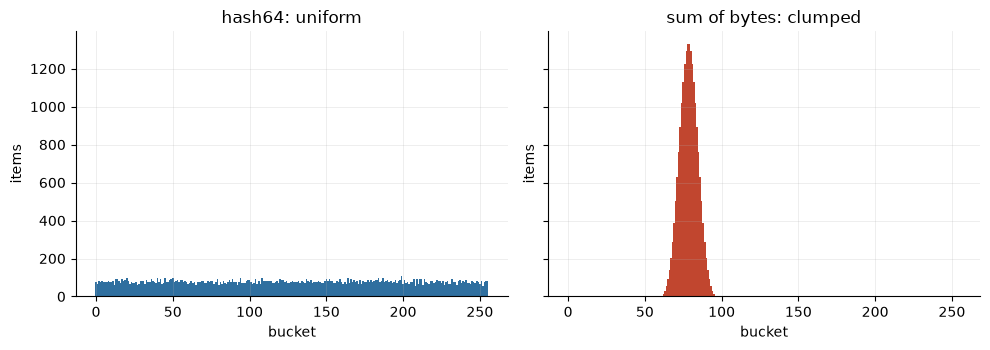

In [4]:
values = [f"user-{i:07d}" for i in range(20_000)]
n_buckets = 256

good_counts = bucket_counts(values, n_buckets, hash64, SEED)
bad_counts = bucket_counts(values, n_buckets, clumping_hash, SEED)

good = chi_square_uniformity(values, n_buckets, hash64, SEED)
bad = chi_square_uniformity(values, n_buckets, clumping_hash, SEED)

print(f"hash64        : chi-square {good.statistic:9.1f}  p = {good.p_value:.3f}  "
      f"fullest bucket is {good.max_over_expected:.2f}x the average  uniform={good.is_uniform}")
print(f"clumping_hash : chi-square {bad.statistic:9.1f}  p = {bad.p_value:.3f}  "
      f"fullest bucket is {bad.max_over_expected:.2f}x the average  uniform={bad.is_uniform}")

figure = plot_bucket_histogram(good_counts, bad_counts)
save_figure(figure, "01_uniformity")
figure

In [5]:
saved = save_results(
    {
        "n_values": len(values),
        "n_buckets": n_buckets,
        "expected_per_bucket": len(values) / n_buckets,
        "hash64": good,
        "clumping_hash": bad,
        "note": (
            "A clumped hash does not fail loudly. It quietly turns O(1) lookups into scans and "
            "inflates every error rate derived from a uniformity assumption."
        ),
    },
    "01_uniformity",
)
print("saved ->", saved.name)

saved -> 01_uniformity.json


## Property 2: avalanche

Uniformity alone is not enough: a hash could spread values evenly and still map neighbouring
inputs to neighbouring outputs, which ruins the moment your keys are sequential ids (they usually
are).

The avalanche test flips one input bit at a time and measures which output bits change. A good
hash sits at 0.5 everywhere - every input bit influences every output bit, half the time. The
figure below is 64 input bits by 64 output bits, and it should be featureless.

hash64        : mean flip rate 0.4997, worst deviation from 0.5 is 0.0710 -> avalanches=True
clumping_hash : mean flip rate 0.0312, worst deviation from 0.5 is 0.5000 -> avalanches=False


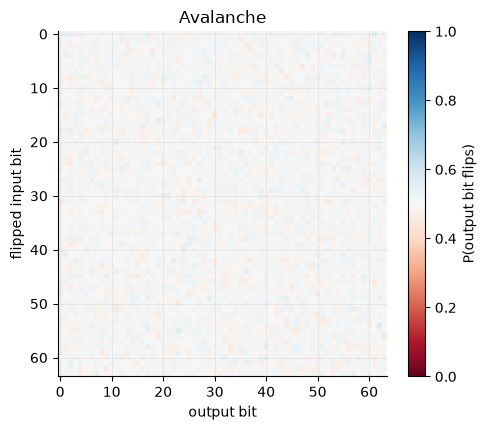

In [6]:
good_avalanche = avalanche_matrix(hash64, n_samples=1_000, seed=SEED)
bad_avalanche = avalanche_matrix(clumping_hash, n_samples=1_000, seed=SEED)

print(f"hash64        : mean flip rate {good_avalanche.mean_flip_rate:.4f}, "
      f"worst deviation from 0.5 is {good_avalanche.worst_deviation:.4f} -> "
      f"avalanches={good_avalanche.avalanches}")
print(f"clumping_hash : mean flip rate {bad_avalanche.mean_flip_rate:.4f}, "
      f"worst deviation from 0.5 is {bad_avalanche.worst_deviation:.4f} -> "
      f"avalanches={bad_avalanche.avalanches}")

figure = plot_avalanche_matrix(good_avalanche.matrix)
save_figure(figure, "01_avalanche_good")
figure

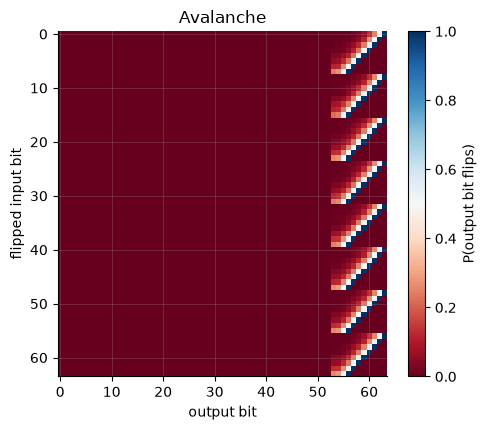

In [7]:
figure = plot_avalanche_matrix(bad_avalanche.matrix)
save_figure(figure, "01_avalanche_bad")
figure

The bad hash's picture is almost entirely one colour: flipping a high input bit changes nothing at
all in the output, because summing bytes throws away position. Sequential user ids would march
straight down a handful of buckets.

In [8]:
saved = save_results(
    {
        "n_samples": good_avalanche.n_samples,
        "hash64": {
            "mean_flip_rate": good_avalanche.mean_flip_rate,
            "worst_deviation": good_avalanche.worst_deviation,
            "avalanches": good_avalanche.avalanches,
        },
        "clumping_hash": {
            "mean_flip_rate": bad_avalanche.mean_flip_rate,
            "worst_deviation": bad_avalanche.worst_deviation,
            "avalanches": bad_avalanche.avalanches,
        },
        "tolerance_note": (
            "The pass/fail band is 5 standard errors of the measurement itself, "
            "sqrt(0.25 / n_samples), not a tuned threshold."
        ),
    },
    "01_avalanche",
)
print("saved ->", saved.name)

saved -> 01_avalanche.json


## Both properties, one table

`hash_quality_report` is what the tests assert against, and what every later notebook assumes is
true of the hash underneath it.

In [9]:
report = hash_quality_report(values=values, n_buckets=n_buckets, n_avalanche_samples=500, seed=SEED)
save_results({"report": report}, "01_hash_quality")
report

,hash,chi_square,p_value,max_over_expected,is_uniform,avalanche_mean,avalanche_worst_deviation,avalanches
0,hash64,258.1248,0.433566,1.3696,True,0.499773,0.086,True
1,clumping_hash,225718.7840,0.000000,17.0240,False,0.030937,0.500,False


## The backend, and why it does not matter much

The fast path is MurmurHash3 (`mmh3`, a small C extension). The fallback is FNV-1a finished
through SplitMix64, in pure Python - slower per call, but it passes exactly the same two tests, so
every structure in this project works without the dependency. That is a deliberate choice: a
teaching repository that cannot run because a wheel is missing teaches nothing.

In [10]:
sample = values[:20_000]

start = time.perf_counter()
_ = [hash64(value, SEED, backend="python") for value in sample]
python_seconds = time.perf_counter() - start

start = time.perf_counter()
_ = [hash64(value, SEED, backend="auto") for value in sample]
fast_seconds = time.perf_counter() - start

fallback_uniformity = chi_square_uniformity(
    sample, n_buckets, lambda value, seed: hash64(value, seed, backend="python"), SEED
)

print(f"mmh3 backend      : {fast_seconds * 1e9 / len(sample):6.0f} ns per hash")
print(f"pure-Python       : {python_seconds * 1e9 / len(sample):6.0f} ns per hash "
      f"({python_seconds / fast_seconds:.1f}x slower)")
print(f"fallback uniform? : {fallback_uniformity.is_uniform} (p = {fallback_uniformity.p_value:.3f})")

saved = save_results(
    {
        "n_hashes": len(sample),
        "mmh3_ns_per_hash": fast_seconds * 1e9 / len(sample),
        "python_ns_per_hash": python_seconds * 1e9 / len(sample),
        "slowdown_factor": python_seconds / fast_seconds,
        "fallback_is_uniform": fallback_uniformity.is_uniform,
        "fallback_p_value": fallback_uniformity.p_value,
    },
    "01_backends",
)
print("saved ->", saved.name)

mmh3 backend      :    503 ns per hash
pure-Python       :   3346 ns per hash (6.7x slower)
fallback uniform? : True (p = 0.218)
saved -> 01_backends.json


## What to take away

- A hash is a deterministic scrambler, and "fast lookup" is just *computing* an address instead of
  searching for it.
- Two measurable properties make one usable: **uniformity** (chi-square finds no clumping) and
  **avalanche** (one input bit flips half the output bits).
- A bad hash does not raise an error. It quietly turns constant-time lookups into scans and
  invalidates every error rate derived from uniformity - which is every error rate in this project.
- Everything that follows is the same primitive pointed at a harder question: a table of items
  (notebook 02), a table of bits (03), a table of maximums (04), a table of minimums (05), a table
  of sums (06).

Next: build the dictionary you already use, and watch it slow down.

In [11]:
takeaways = [
    "Hashing turns 'find this thing' into 'compute where it must be'.",
    "A usable hash needs exactly two properties: uniformity and avalanche.",
    "Both are measurable: chi-square for uniformity, per-bit flip rates for avalanche.",
    "A bad hash fails silently, and takes every downstream error guarantee with it.",
    "The rest of the project is this primitive pointed at harder questions.",
]

save_results({"takeaways": takeaways}, "01_takeaways")

print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("01_*.png")))
print("results:", sorted(path.name for path in results_dir().glob("01_*.json")))

figures: ['01_avalanche_bad.png', '01_avalanche_good.png', '01_uniformity.png']
results: ['01_avalanche.json', '01_backends.json', '01_hash_basics.json', '01_hash_quality.json', '01_takeaways.json', '01_uniformity.json']
